# Optimization for Machine Learning: Computer Lab 1

## 2. Preprocessing the data

Here, we load the data, standardize it, and set it in the appropriate shape for performing linear regression. You do not need to complete anything in this section; however it is important that you understand what the code is doing. See the pdf instructions for more details.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loading data
data_matrix_train, COP_train, data_matrix_test, COP_test, names = np.load('data_center_data_matrix.npy', allow_pickle=True)

In [3]:
# centering and normalizing the matrix
matrix_mean = np.mean(data_matrix_train, axis=0)
M = data_matrix_train - matrix_mean

matrix_std = np.std(M, axis=0)
M = M / matrix_std

In [4]:
M.shape

(722, 892)

In [5]:
# Building the corresponding matrices A,b for linear regression
A = np.hstack([M, np.ones((M.shape[0],1)), -(M.T * COP_train[:,3]).T])
b = COP_train[:,3]

# Building the same matrices for the test set
M_test = (data_matrix_test - matrix_mean) / matrix_std
A_test = np.hstack([M_test, np.ones((M_test.shape[0],1)), -(M_test.T * COP_test[:,3]).T])
b_test = COP_test[:,3]

d = A.shape[1]
N_test = A_test.shape[0]

## 3. Ordinary least squares

We now wish to solve the problem
$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2
$$

Question 3.1:

We have $(Aw)_t = \tilde{x}(t)^{\top}w_1 + w_0 - y(t) \times \tilde{x}(t)^{\top}w_2$ for all $t$ and $b_t = y(t)$.

Suppose we have $Aw = b$. So $(Aw)_t = \tilde{x}(t)^{\top}w_1 + w_0 - y(t) \times \tilde{x}(t)^{\top}w_2 = y(t)$ for all $t$.

Then, we get $\tilde{x}(t)^{\top}w_1 + w_0 = y(t)(1 + \tilde{x}(t)^{\top}w_2)$ for all $t$.

Which gives us $y(t) = \frac{\tilde{x}(t)^{\top}w_1 + w_0}{1 + \tilde{x}(t)^{\top}w_2}$ for all $t$. Since scalar product is symmetric, we get the result.

In [6]:
## Question 3.2: solve with the numpy least squares solver
# COMPLETE HERE
w_least_squares =np.linalg.lstsq(A,b,rcond=None)[0]

In [7]:
## Question 3.3

# COMPLETE HERE
test_error =(1/N_test) * np.linalg.norm((A_test @ w_least_squares - b_test))**2
print("Test error for least squares solution : ", test_error)

Test error for least squares solution :  780.8984793523401


### Adding $\ell_2$ regularization

In order to improve the performance on the test set, we add $\ell_2$ regularization:

$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2 + \frac \lambda 2 \|w\|_2^2
$$

In [8]:
lambda_l2 = 1e4

# Question 3.4

**Gradient of $f_1(w)$:**
$$\nabla f_1(w) = A^T(Aw - b) + \lambda w$$

**Hessian of $f_1(w)$:**
$$\nabla^2 f_1(w) = A^T A + \lambda I_d$$

Since $A^T A$ is positive semi-definite and $\lambda I_d$ is positive definite for $\lambda > 0$, the Hessian is positive definite. 
So this implies that all eigenvalues of the hessian are greater than lambda and thus strictly positive. Therefore, $f_1$ is convex.
Now to know which is the value L for the lipschitz continuity of the gradient, we need to find the maximum eigenvalue of the hessian.
Since the eigenvalues of $A^T A + \lambda I_d$ are equal to the eigenvalues of $A^T A$ plus $\lambda$, we have:
$$L = \lambda_{max}(A^T A) + \lambda$$


In [9]:
# Question 3.5
def f(w):
    return 1/2 * np.linalg.norm((A@w -b))**2 + lambda_l2/2 * np.linalg.norm(w)**2

def grad_f(w):
    return A.T @ (A @ w - b) + lambda_l2 * w

# Gradient descent update formula: w_{t+1} = w_t - gamma * grad_f(w_t)
def gradient_descent(f, grad_f, w0, gamma, max_iter):
    w = w0.copy()
    
    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        # COMPLETE HERE 
        w= w - gamma * grad_f(w)
        if np.linalg.norm(grad_f(w)) <=1:
            print(t)
            break 
        
        f_values.append(f(w))
        gradient_norms.append(np.linalg.norm(grad_f(w)))
        
    return w, f_values, gradient_norms

For finding the appropriate step size range, we need to estimate the Lipschitz constant of the gradient.

By definition, the $\|\cdot\|_2$ norm of a matrix $A$ is its largest singular value, which equals the square root of the largest eigenvalue of $A^T A$. 

Therefore:

In [10]:
L =  np.linalg.norm(A, 2)**2 + lambda_l2
print("Lipschitz constant L =", L)

Lipschitz constant L = 3502543.1053588223


In [11]:
# COMPLETE HERE
w0 = np.ones(d) #d=A.shape[1]
step_size = 1/L
max_iter = 10000

w_GD, f_values_GD, gradient_norms_GD = gradient_descent(f, grad_f, w0, step_size, max_iter)

4412


We need 4412 iterations to reach a gradient norm below 1.

In [12]:
from matplotlib import rcParams

We now compute the evolution of function values and gradient norm. 

Text(0, 0.5, 'Function values')

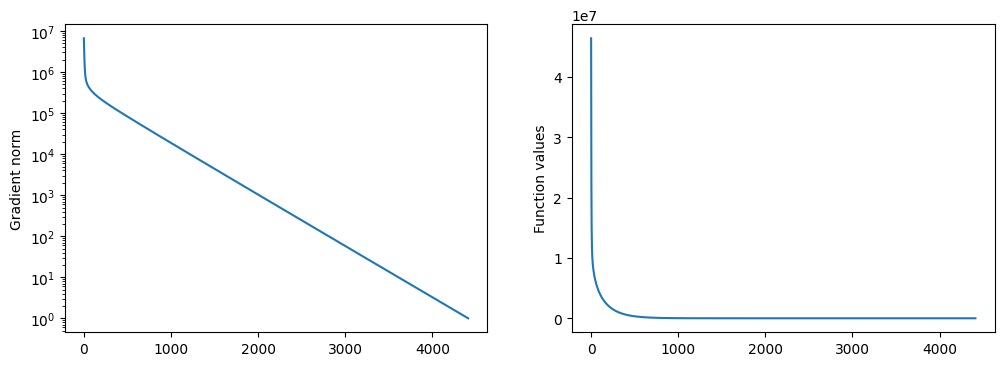

In [13]:
# let us plot the result 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD)
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm")

axes[1].plot(f_values_GD)
axes[1].set_ylabel("Function values")

In [14]:
# Question 3.6 

test_error_l2 = (1/N_test) * np.linalg.norm((A_test @ w_GD - b_test))**2
print("Test error for l2 penalized solution : ", test_error_l2, "vs", test_error)

Test error for l2 penalized solution :  61.48766420175434 vs 780.8984793523401


What do you observe ?

We went from 780 to 61 for the test error, which is a significant improvement. TH ridge regression is way more effiency than ordinary least squares in this case.

### Line search

The step size given by theory is can be too conservative in practice. We propose to implement a backtracking line search procedure to find a better one automatically.


In [15]:
# Question 3.7

def gradient_descent_line_search(f, grad_f, w0, gamma_0, max_iter):
    w = w0.copy()

    # initial step size
    gamma = gamma_0.copy() 
    
    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        # COMPLETE HERE
        while f(w-gamma*grad_f(w))>f(w)-gamma/2 * np.linalg.norm(grad_f(w))**2:    
            gamma= gamma/2
        w= w - gamma * grad_f(w)
        gamma= gamma*2          
        f_values.append(f(w))
        gradient_norms.append(np.linalg.norm(grad_f(w)))
        
    return w, f_values, gradient_norms

In [16]:
# COMPLETE HERE
w0 = np.ones(d) #d=A.shape[1]
step_size = 1/L
max_iter = 5000

w_GD_LS, f_values_GD_LS, gradient_norms_GD_LS = gradient_descent_line_search(f, grad_f, w0, step_size, max_iter)

Text(0, 0.5, 'Function values with line search')

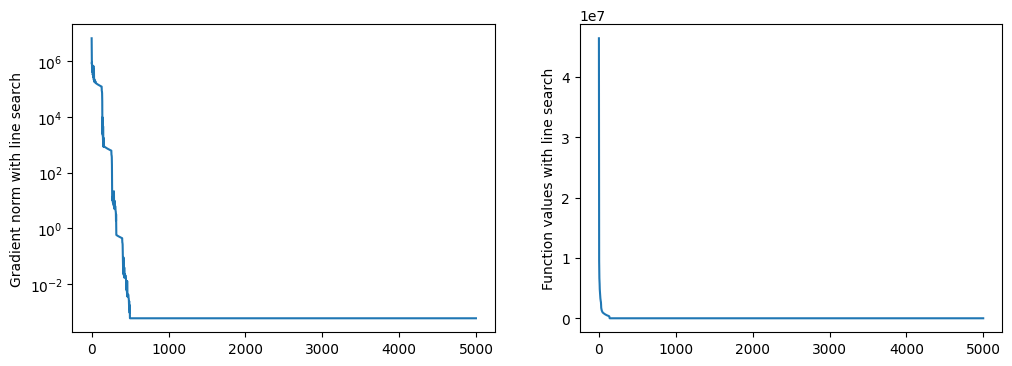

In [17]:
# let us plot the result 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD_LS)
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm with line search")

axes[1].plot(f_values_GD_LS)
axes[1].set_ylabel("Function values with line search")

### Accelerated gradient method
For a faster algorithm, we could implement accelerated gradient descent.

In [21]:
# Question 3.8 (optional) 

def accelerated_gradient_descent(f, grad_f, w0, gamma, max_iter):
    y = w0.copy()
    x = w0.copy() #x0 =y0 au début
    f_values = []
    gradient_norms = []
    for t in range(max_iter):
        y_old= y.copy()
        y= x - gamma * grad_f(y)
        beta_t = (t + 1) / (t + 4)
        x= y + beta_t * (y - y_old)
        f_values.append(f(x))
        gradient_norms.append(np.linalg.norm(grad_f(x)))
    return x, f_values, gradient_norms

In [22]:
# COMPLETE HERE
w0 = np.ones(d) #d=A.shape[1]
step_size = 1/L
max_iter = 5000

w_AGD, f_values_AGD, gradient_norms_AGD = accelerated_gradient_descent(f, grad_f, w0, step_size, max_iter)

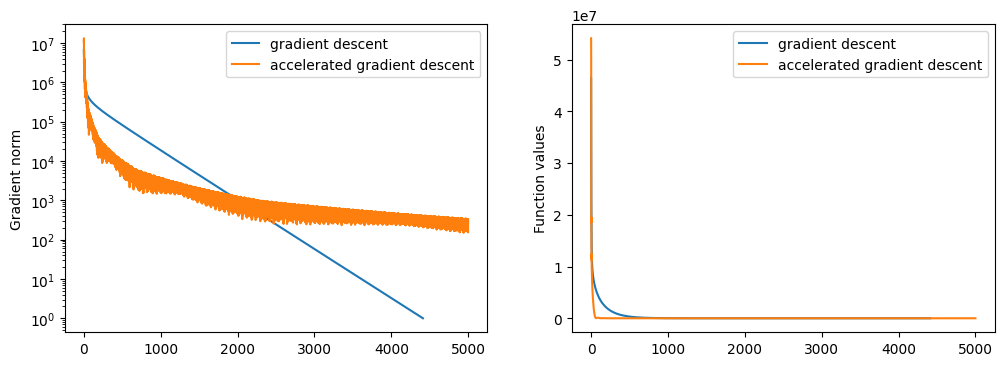

In [23]:
# let us plot the result 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD, label = "gradient descent")
axes[0].plot(gradient_norms_AGD, label = "accelerated gradient descent")
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm")
axes[0].legend()

axes[1].plot(f_values_GD, label = "gradient descent")
axes[1].plot(f_values_AGD, label = "accelerated gradient descent")
axes[1].set_ylabel("Function values")
axes[1].legend()

What do you observe regarding the convergence speed ?

## 4. Adding $\ell_1$ regularization (Lasso)

We now solve 

$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2 + \lambda \|w\|_1
$$

## Question 4.1

We decompose the objective function as:
$$F_2(w) = f_2(w) + g_2(w)$$

where:
- $f_2(w) = \frac{1}{2}\|Aw - b\|_2^2$ (differentiable part)
- $g_2(w) = \lambda \|w\|_1$ (non-smooth part with easy proximal operator)

**Gradient of $f_2(w)$:**
$$\nabla f_2(w) = A^T(Aw - b)$$

**Proximal operator of $g_2(w)$:**

The proximal operator of $g_2(w)$ is $argmin_z (g_2(z) + \frac{1}{2}\|z - w\|_2^2)$ = $argmin_z (\lambda \|z\|_1 + \frac{1}{2}\|z - w\|_2^2)$
$$prox_{\lambda \|.\|_1}(x) = sign(x) \cdot max(|x| - \lambda, 0)$$

In [24]:
lambda_l1 = 1e3

## Question 4.2
def prox_l1(x, mu):
    """compute the proximal operator of mu * |x|_1
    """
    return np.sign(x) * np.maximum(np.abs(x) - mu, 0)
    

def proximal_gradient_descent(f, grad_f, w0, gamma, max_iter):
    w = w0.copy()

    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        w_old= w.copy()
        z = w - gamma * grad_f(w)
        w = prox_l1(z,gamma * lambda_l1)
        f_values.append(f(w))
        gradient_norms.append(np.linalg.norm(grad_f(w)))
        
    return w, f_values, gradient_norms

In [25]:
# COMPLETE HERE
w0 = np.ones(d) #d=A.shape[1]
step_size = 1/L
max_iter = 5000

w_PGD, f_values_PGD, gradient_norms_PGD = proximal_gradient_descent(f, grad_f, w0, step_size, max_iter)

In [26]:
# Question 4.3

test_error_l1 = (1/N_test) * np.linalg.norm((A_test @ w_PGD - b_test))**2
print("Test error for l1 penalized solution : ", test_error_l1)

Test error for l1 penalized solution :  17.13914184376626


Compare with the previous test errors. What do you observe?

We had a test error of 61 with l2 regularization and now we have 17 with l1 regularization. So we can see that l1 regularization gives a better test error in this case.

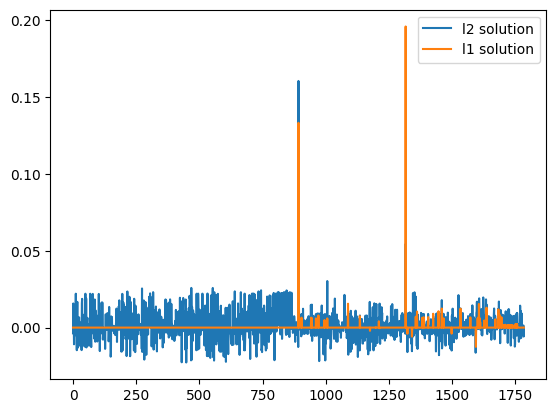

In [27]:
# Let us examine the solution
plt.plot(w_GD, label = "l2 solution")
plt.plot(w_PGD, label = "l1 solution")
plt.legend()

The L1 solution is sparse (most coefficients are exactly zero), while the L2 solution is noisy (all coefficients are non-zero but small). This is a key characteristic of L1 regularization: it performs automatic feature selection by driving many coefficients to exactly zero, whereas L2 regularization only shrinks coefficients toward zero but rarely sets them exactly to zero.

## [BONUS] Tuning the penalization parameter

How to find the best solution among all those that were comptued? How to choose the penalization parameter $\lambda$?

In [ ]:
# Your method here...